
For a past project, I was exploring options for a high-performance alternative to NetworkX for large networks. I attended a breakout session at the Scipy conference focusing on cuGraph from the NVIDIA RAPIDS project, and was intrigued. 

[cuGraph](https://github.com/rapidsai/cugraph) is part of NVIDIA's RAPIDS ecosystem. It is a GPU-accelerated graph analytics library designed to feel familiar to NetworX users while running expensive graph algorithms on CUDA-enabled GPUs. The performance difference matters most for algorithms like betweenness centrality, which repeatedly explores shortest paths from many source nodes and becomes very slow on large road networks in NetworkX. cuGraph moves the graph representation and traversal work onto the GPU, where thousands of lightweight threads can process frontier expansions and path dependencies in parallel. For road network analysis, a calculation that may be impractical in NetworkX can become feasible, especially when using approximate betweenness with a sampled set of source nodes.

This article is divided into three main sections:

1. Introduction to betweenness centrality as a measure of criticality in road networks. 
2. How to represent a road network sourced from OpenStreetMap as an undirected graph using OSMnx.
3. Comparison of betweenness centrality using NetworkX and cuGraph.

To ensure an apples-to-apples comparison, the benchmarks use unweighted betweenness centrality. NetworkX supports weighted shortest paths (using distance or travel time), but the current cuGraph implementation uses unweighted BFS traversals and does not support edge weights.



### **Betweenness Centrality**

A widely used measure in network analysis is betweenness centrality, which quantifies the extent to which a node lies on the shortest paths connecting other nodes in a graph. A node having high betweenness centrality acts as a bridge or bottleneck through which traffic flows. In transportation networks, intersections with high betweenness centrality typically correspond to critical roadway junctions that connect different parts of a city. Disruptions at these locations can have an outsized impact on overall traffic flow, which makes betweenness centrality a useful tool for understanding how movement occurs throughout a road network.

The betweenness centrality of node $v$ is defined as:

$$
C_B(v) = \sum_{s \neq v \neq t}
\frac{\sigma_{st}(v)}
{\sigma_{st}},
$$

where:

* $\sigma_{st}$ is the total number of shortest paths between nodes $s$ and $t$,
* $\sigma_{st}(v)$ is the number of those shortest paths that pass through node $v$.

A node receives a high score when it appears frequently on shortest paths connecting other pairs of nodes. Nodes located on the periphery of a network or within highly redundant regions tend to receive lower scores because alternative shortest paths exist that bypass them.


Both NetworkX and cuGraph betweenness centrality implementations are based on an algorithm developed by [Brandes (2001)](https://snap.stanford.edu/class/cs224w-readings/brandes01centrality.pdf), which reduces the computational cost of calculating betweenness centrality compared to a naive all-pairs shortest path approach. The algorithm performs a shortest path traversal from each source node, tracks the number of shortest paths reaching each destination, and then accumulates dependency scores in a reverse pass. This reduces the computational complexity to $O(VE)$ ($V$ = vertices, $E$ = edges) for unweighted graphs vs. roughly $O(V^2E)$ if computing a shortest-path search independently for every pair of vertices. At a high level, the algorithm can be summarized as:

```text
For source node s:

    Perform BFS (breadth-first search) starting from s

    For each discovered node v record:

        distance[v]:
            Shortest distance from s to v

        sigma[v]:
            Number of shortest paths from s to v

        predecessors[v]:
            Nodes immediately preceding v on a shortest path from s
```

<br>


During the BFS traversal, we not only determine how far each node is from the source, but also how many equally short ways exist to reach it. This allows the algorithm to distribute centrality credit fairly when multiple shortest paths connect the same pair of nodes.


A simple implementation of the Brandes algorithm is provided in the next cell. 


In [ ]:

from collections import deque


def brandes_algorithm(graph):

    nodes = graph.keys()

    # Initialize betweenness dict. 
    betweenness = {v: 0.0 for v in nodes}

    for s in nodes:
        # Stack of nodes in order of non-decreasing distance from s,
        # used to process nodes in reverse BFS order during the
        # dependency accumulation phase.
        stack = []

        # For each node, the list of predecessors on shortest paths
        # from s.
        predecessors = {v: [] for v in nodes}

        # Number of shortest paths from s to each node.
        sigma = {v: 0 for v in nodes}
        sigma[s] = 1

        # Distance from s to each node. -1 means unvisited.
        dist = {v: -1 for v in nodes}
        dist[s] = 0

        # BFS frontier.
        queue = deque([s])

        # Forward pass: BFS from s to find shortest paths and
        # populate sigma, dist, and predecessors.
        while queue:
            v = queue.popleft()
            stack.append(v)

            for w in graph[v]:
                # First visit to w: assign distance and enqueue.
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1

                # Edge (v, w) lies on a shortest path to w: update
                # path count and record v as a predecessor of w.
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    predecessors[w].append(v)

        # Dependency of s on each node, accumulated during the
        # backward pass.
        delta = {v: 0.0 for v in nodes}

        # Backward pass: process nodes in reverse BFS order,
        # propagating dependency scores up to predecessors.
        while stack:
            w = stack.pop()
            for v in predecessors[w]:

                # Fraction of shortest paths through v that extend
                # to w, scaled by w's total accumulated dependency.
                delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])

            # Add w's dependency to its betweenness score, excluding
            # the source node s.
            if w != s:
                betweenness[w] += delta[w]

    return betweenness



In the backward pass, we have:

```
delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
```

`delta[v]` is the dependency of source `s` on node `v`, which represents the fraction of all shortest paths originating from `s` that pass through `v`. After the backward pass completes, this value gets added to `v`'s betweenness score.

For a predecessor `v` of `w` on shortest paths from `s`:

- `sigma[v] / sigma[w]`: The fraction of shortest paths to `w` that came through `v`. If there are 6 shortest paths to `w` and 2 of them passed through `v`, this is 2/6.

- `1 + delta[w]`: The 1 counts `w` itself as a destination. `delta[w]` carries the accumulated dependency from all nodes beyond `w` that were already processed. Deeper nodes get processed first, so by the time you handle `w`, its delta is already fully built up.

- Multiplying them together gives `v`'s share of the paths that flow through `w` onward.





  
### **Constructing the Graph: OSM Roads as Nodes and Edges**

In previous posts I demonstrated how OpenStreetMap can be leveraged to programmatically identify points of interest, with one example showing how to locate and extract every fire station and hospital within a given state. The OpenStreetMap data files also contain driving, walking, and cycling networks. Working with these networks is greatly simplified using OSMnx, which allows us to model and analyze street networks from OpenStreetMap in Python, with built-in support for graph-theoretic analysis.


![The road network used to demonstrate betweenness centrality.](gb03.png){fig-align="center" width="50%"}


The road network can be loaded from the OpenStreetMap OverPass API directly. We pass in the bounding region of interest and include `retain_all=False`, which tells OSMnx to keep only the largest connected component of the road network and discard smaller disconnected pieces. In the next cell, we load the road network from the Des Moines metro region.


In [ ]:

import geopandas as gpd
import pandas as pd
import osmnx as ox


# Des Moines metro bounding region.
bbox = [-93.8218, 41.4900, -93.4696, 41.6770]

# Get driving network as MultiDiGraph using OverPass API.
G_directed = ox.graph_from_bbox(
    bbox,
    network_type="drive",
    simplify=True,
    retain_all=False
)

# Transform to undirected graph.
G = ox.convert.to_undirected(G_directed)

# Save graph and to file so as not to overburden the API. 
ox.save_graphml(G, "des-moines-road-network.graphml")

print(f"Filtered network: {len(G):,} nodes, {len(G.edges):,} edges")


Filtered network: 12,869 nodes, 19,053 edges



The road network can be visualized via `ox.plot_graph`. `node_size` is set to 0 to allow for a clearer view of the road segments.    

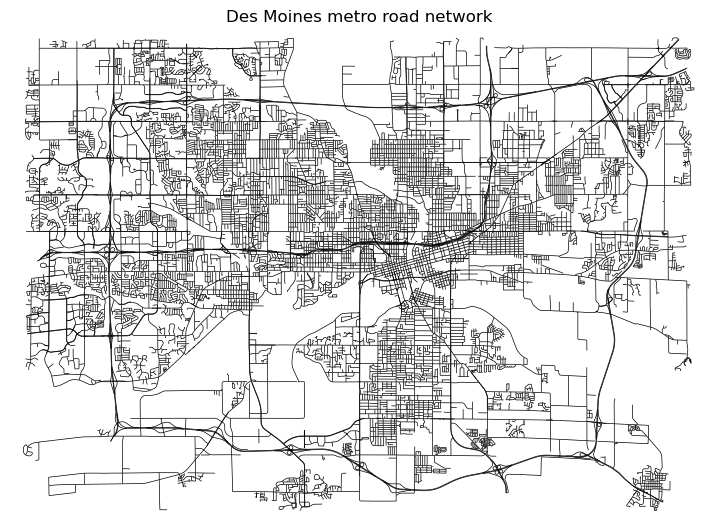

In [13]:

import matplotlib.pyplot as plt

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="#000000",
    edge_linewidth=0.5,
    bgcolor="#FFFFFF",
    show=False,
    close=False,
    figsize=(9, 6.5),
)

ax.set_title(
    "Des Moines metro road network",
    fontsize=12,
    pad=5
)

ax.set_axis_off()

plt.show()



#### **NetworkX Betweenness Centrality**
   
Computing betweenness centrality in NetworkX is a one-liner. `normalize=True` rescales the raw betweenness scores so they lie roughly between 0 and 1, where a score of 0 means the node lies on essentially no shortest paths, and 1 the node lies on nearly every shortest path possible (`normalize=True` is also supplied for cuGraph's betweenness centrality).


In [14]:

import networkx as nx
from time import perf_counter

t_i = perf_counter()
bc = nx.betweenness_centrality(G, normalized=True)
t_total = perf_counter() - t_i

print(f"NetworkX betweenness centrality runtime : {t_total:.2f} seconds.")


NetworkX betweenness centrality runtime : 918.07 seconds.



Visualizing the top 25 nodes in terms of betweenness centrality:

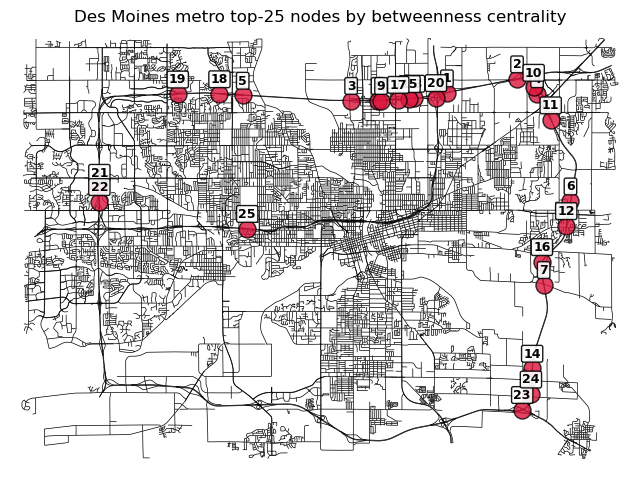

In [ ]:

top25 = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:25]
nodes = [n for n, c in top25]
scores = [c for n, c in top25]
xs = [G.nodes[n]["x"] for n in nodes]
ys = [G.nodes[n]["y"] for n in nodes]

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="#000000",
    edge_linewidth=0.5,
    bgcolor="white",
    show=False,
    close=False,
)

ax.set_title("Des Moines metro top-25 nodes by betweenness centrality")
ax.scatter(
    xs,
    ys,
    s=150,
    c="crimson",
    alpha=0.8,
    edgecolors="black",
)

for rank, (x, y) in enumerate(zip(xs, ys), start=1):
    ax.annotate(
        str(rank),
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15",
            fc="white",
            ec="black",
            alpha=0.9,
        ),
    )

plt.show()



A table with top-25 nodes in terms of betweenness centrality along with additional detail from OSM:

In [23]:

rows = []

for rank, (node, score) in enumerate(top25, start=1):
    attrs = G.nodes[node]
    rows.append({
        "Rank": rank,
        "Node": node,
        "Exit": attrs.get("ref", ""),
        "Type": attrs.get("highway", ""),
        "Street Count": attrs.get("street_count", ""),
        "Longitude": attrs["x"],
        "Latitude": attrs["y"],
        "Betweenness": score,
    })

df_top25 = pd.DataFrame(rows)

df_top25["Betweenness"] = df_top25["Betweenness"].round(3)
df_top25["Longitude"] = df_top25["Longitude"].round(5)
df_top25["Latitude"] = df_top25["Latitude"].round(5)

df_top25

,Rank,Node,Exit,Type,Street Count,Longitude,Latitude,Betweenness
0,1,160724511,,,3,-93.56999,41.65276,0.153
1,2,160751259,141,motorway_junction,3,-93.52828,41.65899,0.152
2,3,160748417,135,motorway_junction,3,-93.62699,41.64939,0.144
3,4,160740876,83,motorway_junction,3,-93.51635,41.65239,0.144
4,5,160754178,,,3,-93.69146,41.65171,0.142
5,6,160753519,79,motorway_junction,3,-93.49650,41.60467,0.136
6,7,566815867,,,3,-93.51245,41.56745,0.136
7,8,160773224,,,3,-93.61126,41.64940,0.136
8,9,160756064,136,motorway_junction,3,-93.60919,41.64938,0.135
9,10,160751327,,,3,-93.51838,41.65523,0.132



<br>

The highest-betweenness intersections are almost exclusively highway interchanges. Although downtown contains the densest concentration of roads, as we mentioned earlier, nodes within highly redundant regions tend to receive lower scores because alternative shortest paths exist that bypass them. The interstate system carries the majority of shortest paths through the network. This mostly aligns with what I expected, with one exception: The node representing the intersection of I-35 and I-80 is ranked 21st, which I thought would be much higher. 


<br>

#### **cuGraph Betweenness Centrality**  

To determine betweenness centrality using cuGraph, we first need to convert the OSMnx graph into an edge list representation. For this evaluation, a single NVIDIA T4 Tensor Core GPU with 16GB VRAM was used running in SageMaker. 

In [ ]:

import cudf
import cugraph

# Convert NetworkX graph to edge list.
edges = (
    ox.graph_to_gdfs(G, nodes=False)
      .reset_index()[["u", "v"]]
)

# Convert to cuDF.
edges_cu = cudf.from_pandas(edges)

# Build undirected cuGraph graph.
G_cu = cugraph.Graph(directed=False)
G_cu.from_cudf_edgelist(
    edges_cu,
    source="u",
    destination="v",
    renumber=True,
)

t_i = perf_counter()
cu_bc = cugraph.betweenness_centrality(G_cu, normalized=True)
t_total = perf_counter() - t_i
print(f"cuGraph betweenness centrality runtime : {t_total:.2f} seconds.")


cuGraph betweenness centrality runtime : 4.17 seconds.


<br>

On the Des Moines driving network, exact unweighted betweenness centrality took 15 minutes in NetworkX but only 4.17 seconds in cuGraph using a single NVIDIA T4 GPU, over a 200× speedup. Both implementations use the Brandes algorithm, but cuGraph executes the workload using GPU-parallel compiled kernels over optimized numeric graph structures. In NetworkX, most of that happens through Python object dictionaries, NetworkX node objects and interpreted loops. 

GPU acceleration fundamentally changes what is practical in graph analytics. cuGraph can reduce the runtime of computationally intensive algorithms like betweenness centrality from minutes or hours to seconds. This level of performance transforms graph algorithms from long-running overnight batch computations into interactive analytical tools, which is incredibly powerful. 

Next time we'll explore GraphBLAS, an open standard for expressing graph algorithms in terms of sparse linear algebra operations, allowing algorithms like BFS to be implemented as combinations of sparse matrix and vector computations. This enables concise implementations that can leverage highly optimized linear algebra libraries for exceptional performance.
